#### Do task orderings follow a shared cross-occupation logic? A DWA-ordering consistency test
#### By: Peyman Shahidi
#### Created: 2026-07-25

**Concern being tested.** The Prediction-3 identification uses the same step (tasks in the same DWA) appearing in
different occupations with different neighbors. If every occupation orders its tasks by the same logic, then a
DWA-1 task would systematically sit next to a DWA-2 task in *every* occupation where both appear: cross-occupation
"variation" in neighbors would be less informative, since local context would be pinned down by task content.
Concretely: if DWA 1's task X is immediately preceded by DWA 2's task Y in occupation A, is DWA 1's task X' also
immediately preceded by DWA 2's task Y' in occupation B?

**Two measures.**
1. **Adjacency recurrence (the example above, literally).** Map each occupation's ordered workflow to DWAs and
   collect all ordered adjacent DWA pairs (task at position t-1 in DWA j, task at position t in DWA k, j != k,
   adjacency in the full workflow). Statistic: the share of adjacent-pair observations whose ordered DWA pair also
   appears as an adjacent pair in at least one other occupation (and, separately, in at least two different SOC
   major groups). Also reported at the level of distinct pairs.
2. **Pairwise direction agreement (general ordering logic).** For every unordered DWA pair present together in two
   or more occupations, record in each occupation which DWA comes first (mean position of its tasks). Statistic:
   the probability that two randomly chosen occupations sharing the pair order it the same way, aggregated over
   all such occupation pairs (and, separately, over occupation pairs from different SOC major groups).

**Null.** Both statistics have nonzero baselines by construction (frequent DWAs recur by chance; agreement is
about one half by chance). We therefore compare each observed value against 1,000 placebo draws that reshuffle
task order within each occupation, keeping every occupation's task and DWA composition fixed. This is the same
randomization logic as the paper's placebo exercise.

**Task universe.** Mirrors the Prediction-3 sample filters: tasks mapped to exactly one DWA, and DWAs whose tasks
appear in more than one occupation. Unmapped tasks stay in the sequences (they break adjacency but carry no DWA).

**Outputs.** `data/computed_objects/dwaOrdering_consistency/` (CSVs) and `writeup/plots/dwaOrdering_consistency/`
(null-distribution figures).

In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200); pd.set_option('display.width', 220)

In [2]:
N_SHUFFLES = 1000
SEED = 123

main_folder_path = ".."
input_data_path = f"{main_folder_path}/data"
merged_file = f"{input_data_path}/computed_objects/ONET_Eloundou_Anthropic_GPT/ONET_Eloundou_Anthropic_GPT.csv"
mapping_file = f"{input_data_path}/computed_objects/similar_dwa_tasks/dwa_task_mapping.csv"
output_data_path = f"{input_data_path}/computed_objects/dwaOrdering_consistency"
output_plot_path = f"{main_folder_path}/writeup/plots/dwaOrdering_consistency"
for p in [output_data_path, output_plot_path]: os.makedirs(p, exist_ok=True)

## Build the occupation workflows with DWA labels

A task is "mapped" when it belongs to exactly one DWA and that DWA spans more than one occupation (the
Prediction-3 universe). All other tasks remain in the sequence as unmapped placeholders so that adjacency in the
full workflow is preserved.

In [3]:
mapping = pd.read_csv(mapping_file)
n_dwas_per_task = mapping.groupby('Task ID')['DWA ID'].nunique()
unique_task_ids = set(n_dwas_per_task[n_dwas_per_task == 1].index)

d = pd.read_csv(merged_file)[['O*NET-SOC Code', 'Occupation Title', 'Task ID', 'Task Title',
                              'Task Position', 'Major_Group_Code']].copy()
d['Task Position'] = pd.to_numeric(d['Task Position'], errors='coerce')
d = d.dropna(subset=['Task Position']).drop_duplicates(['O*NET-SOC Code', 'Task ID']).reset_index(drop=True)

map1 = mapping[mapping['Task ID'].isin(unique_task_ids)][['Task ID', 'O*NET-SOC Code', 'DWA ID', 'DWA Title']].drop_duplicates()
d = d.merge(map1, on=['Task ID', 'O*NET-SOC Code'], how='left')

# multi-occupation DWAs only (identification-relevant universe)
occs_per_dwa = d.dropna(subset=['DWA ID']).groupby('DWA ID')['O*NET-SOC Code'].nunique()
multi_occ_dwas = set(occs_per_dwa[occs_per_dwa > 1].index)
d['dwa_eff'] = d['DWA ID'].where(d['DWA ID'].isin(multi_occ_dwas))
d['mapped'] = d['dwa_eff'].notna()

d = d.sort_values(['O*NET-SOC Code', 'Task Position']).reset_index(drop=True)
OCC, occ_index = pd.factorize(d['O*NET-SOC Code'])
MGrow, mg_index = pd.factorize(d['Major_Group_Code'])
DWA_OBS, dwa_index = pd.factorize(d['dwa_eff'])          # NaN -> -1 (unmapped)
K = len(dwa_index); NOCC = int(OCC.max()) + 1; NMG = int(MGrow.max()) + 1
dwa_title = dict(d.dropna(subset=['dwa_eff'])[['dwa_eff', 'DWA Title']].drop_duplicates().values)

print(f"task-rows in sequences: {len(d):,} across {NOCC} occupations ({NMG} SOC major groups)")
print(f"mapped tasks (single-DWA, multi-occupation DWA): {int(d['mapped'].sum()):,} ({d['mapped'].mean():.1%}) "
      f"across {len(multi_occ_dwas):,} DWAs")

task-rows in sequences: 17,920 across 872 occupations (22 SOC major groups)
mapped tasks (single-DWA, multi-occupation DWA): 13,407 (74.8%) across 1,888 DWAs


## Measure A: recurrence of ordered adjacent DWA pairs across occupations

In [4]:
same_occ = OCC[1:] == OCC[:-1]
occ_of_pair = OCC[1:].astype(np.int64)
mg_of_pair = MGrow[1:].astype(np.int64)

def adjacency_stats(dwa_seq):
    """Recurrence of ordered adjacent DWA pairs (j != k) across occupations and SOC major groups."""
    d1 = dwa_seq[:-1]; d2 = dwa_seq[1:]
    valid = same_occ & (d1 >= 0) & (d2 >= 0)
    self_share = float((d1[valid] == d2[valid]).mean())
    keep = valid & (d1 != d2)
    p1 = d1[keep].astype(np.int64); p2 = d2[keep].astype(np.int64)
    po = occ_of_pair[keep]; pm = mg_of_pair[keep]
    pair = p1 * K + p2
    uo = np.unique(pair * NOCC + po); up_o = uo // NOCC
    pu, cnt = np.unique(up_o, return_counts=True)
    occs_per = cnt[np.searchsorted(pu, pair)]
    um = np.unique(pair * NMG + pm); up_m = um // NMG
    pum, cntm = np.unique(up_m, return_counts=True)
    mgs_per = cntm[np.searchsorted(pum, pair)]
    return {'n_adj_pairs': int(len(pair)),
            'self_dwa_share': self_share,
            'obs_recur_occ': float((occs_per >= 2).mean()),
            'obs_recur_mg': float((mgs_per >= 2).mean()),
            'pair_recur_occ': float(np.unique(pair[occs_per >= 2]).size / np.unique(pair).size)}

obsA = adjacency_stats(DWA_OBS)
print("Observed (adjacent task pairs with both tasks mapped, different DWAs):")
print(f"  adjacent-pair observations:                      {obsA['n_adj_pairs']:,}")
print(f"  share of adjacencies within the same DWA:        {obsA['self_dwa_share']:.3f}  (excluded below)")
print(f"  obs-level recurrence, >=2 occupations:           {obsA['obs_recur_occ']:.3f}")
print(f"  obs-level recurrence, >=2 SOC major groups:      {obsA['obs_recur_mg']:.3f}")
print(f"  pair-level recurrence (distinct ordered pairs):  {obsA['pair_recur_occ']:.3f}")

# pair-level table for the top-recurring adjacencies
_d1 = DWA_OBS[:-1]; _d2 = DWA_OBS[1:]
keep_mask = same_occ & (_d1 >= 0) & (_d2 >= 0) & (_d1 != _d2)
adj = pd.DataFrame({'slot': np.where(keep_mask)[0],
                    'd1': _d1[keep_mask].astype(np.int64), 'd2': _d2[keep_mask].astype(np.int64),
                    'occ': OCC[1:][keep_mask]})
adj['pair'] = adj['d1'] * K + adj['d2']
pstats = adj.groupby('pair').agg(n_obs=('occ', 'size'), n_occ=('occ', 'nunique')).reset_index()
pstats['dwa_prev'] = pstats['pair'] // K; pstats['dwa_next'] = pstats['pair'] % K
pstats['dwa_prev_title'] = [dwa_title[dwa_index[i]] for i in pstats['dwa_prev']]
pstats['dwa_next_title'] = [dwa_title[dwa_index[i]] for i in pstats['dwa_next']]
top = pstats.sort_values(['n_occ', 'n_obs'], ascending=False).head(100)
top[['dwa_prev_title', 'dwa_next_title', 'n_occ', 'n_obs']].to_csv(
    f"{output_data_path}/top_recurring_dwa_adjacencies.csv", index=False)
print("\nTop 10 recurring ordered DWA adjacencies (prev DWA -> next DWA, # occupations):")
for _, r in top.head(10).iterrows():
    print(f"  [{r['n_occ']:>3} occs] {r['dwa_prev_title'][:70]}  ->  {r['dwa_next_title'][:70]}")

Observed (adjacent task pairs with both tasks mapped, different DWAs):
  adjacent-pair observations:                      8,509
  share of adjacencies within the same DWA:        0.132  (excluded below)
  obs-level recurrence, >=2 occupations:           0.157
  obs-level recurrence, >=2 SOC major groups:      0.003
  pair-level recurrence (distinct ordered pairs):  0.067

Top 10 recurring ordered DWA adjacencies (prev DWA -> next DWA, # occupations):
  [ 30 occs] Serve on institutional or departmental committees.  ->  Direct department activities.
  [ 23 occs] Evaluate student work.  ->  Maintain student records.
  [ 16 occs] Maintain student records.  ->  Advise students on academic or career matters.
  [ 15 occs] Develop instructional materials.  ->  Compile specialized bibliographies or lists of materials.
  [ 15 occs] Advise students on academic or career matters.  ->  Supervise student research or internship work.
  [ 14 occs] Research topics in area of expertise.  ->  Serve on in

In [5]:
# Concrete X/Y examples: the same ordered DWA adjacency realized by different tasks in different occupations
print("Examples in the X / Y notation (DWA 2's task Y immediately precedes DWA 1's task X):\n")
for _, r in top.head(3).iterrows():
    rows = adj[adj['pair'] == r['pair']]
    first_by_occ = rows.groupby('occ', as_index=False).first().head(3)
    print(f"DWA 2 = '{r['dwa_prev_title'][:60]}'  ->  DWA 1 = '{r['dwa_next_title'][:60]}'"
          f"  (adjacent in {r['n_occ']} occupations)")
    for _, rr in first_by_occ.iterrows():
        s = int(rr['slot'])
        occ_t = d.iloc[s + 1]['Occupation Title']
        y_t = d.iloc[s]['Task Title'][:70]; x_t = d.iloc[s + 1]['Task Title'][:70]
        print(f"   [{occ_t}]")
        print(f"      Y: '{y_t}'")
        print(f"      X: '{x_t}'")
    print()

Examples in the X / Y notation (DWA 2's task Y immediately precedes DWA 1's task X):

DWA 2 = 'Serve on institutional or departmental committees.'  ->  DWA 1 = 'Direct department activities.'  (adjacent in 30 occupations)
   [Business Teachers, Postsecondary]
      Y: 'Serve on academic or administrative committees that deal with institut'
      X: 'Perform administrative duties, such as serving as department head.'
   [Computer Science Teachers, Postsecondary]
      Y: 'Serve on academic or administrative committees that deal with institut'
      X: 'Perform administrative duties, such as serving as department head.'
   [Mathematical Science Teachers, Postsecondary]
      Y: 'Serve on academic or administrative committees that deal with institut'
      X: 'Perform administrative duties, such as serving as department head.'

DWA 2 = 'Evaluate student work.'  ->  DWA 1 = 'Maintain student records.'  (adjacent in 23 occupations)
   [Mathematical Science Teachers, Postsecondary]
      Y: 

### Measure A null: reshuffle task order within occupations (1,000 draws)

statistic                                   observed  null mean  null sd       z  p (null >= obs)
obs-level recurrence (>=2 occupations)         0.157      0.102   0.0036   15.26           0.0010
obs-level recurrence (>=2 major groups)        0.003      0.002   0.0007    1.14           0.1289
pair-level recurrence (>=2 occupations)        0.067      0.048   0.0019   10.12           0.0010
share of same-DWA adjacencies                  0.132      0.046   0.0018   46.90           0.0010


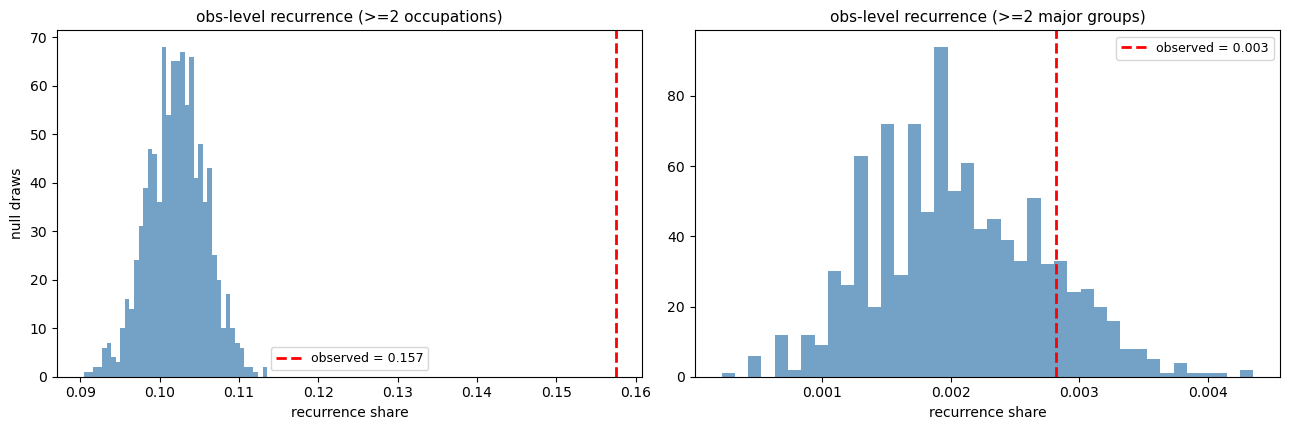

In [6]:
rng = np.random.default_rng(SEED)
n_rows = len(d)
nullA_rows = []
for b in range(N_SHUFFLES):
    order = np.lexsort((rng.random(n_rows), OCC))
    nullA_rows.append(adjacency_stats(DWA_OBS[order]))
nullA = pd.DataFrame(nullA_rows)
nullA.to_csv(f"{output_data_path}/null_draws_measureA.csv", index=False)

print(f"{'statistic':<42}{'observed':>10}{'null mean':>11}{'null sd':>9}{'z':>8}{'p (null >= obs)':>17}")
A_KEYS = ['obs_recur_occ', 'obs_recur_mg', 'pair_recur_occ', 'self_dwa_share']
A_LABEL = {'obs_recur_occ': 'obs-level recurrence (>=2 occupations)',
           'obs_recur_mg': 'obs-level recurrence (>=2 major groups)',
           'pair_recur_occ': 'pair-level recurrence (>=2 occupations)',
           'self_dwa_share': 'share of same-DWA adjacencies'}
summaryA = []
for k in A_KEYS:
    mu, sd = nullA[k].mean(), nullA[k].std(ddof=1)
    z = (obsA[k] - mu) / sd if sd > 0 else np.nan
    p = (1 + (nullA[k] >= obsA[k]).sum()) / (1 + N_SHUFFLES)
    print(f"{A_LABEL[k]:<42}{obsA[k]:>10.3f}{mu:>11.3f}{sd:>9.4f}{z:>8.2f}{p:>17.4f}")
    summaryA.append({'measure': 'A_adjacency', 'statistic': k, 'observed': obsA[k],
                     'null_mean': mu, 'null_sd': sd, 'z': z, 'p_onesided_greater': p})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, k in zip(axes, ['obs_recur_occ', 'obs_recur_mg']):
    ax.hist(nullA[k], bins=40, color='steelblue', alpha=0.75)
    ax.axvline(obsA[k], color='red', ls='--', lw=2, label=f"observed = {obsA[k]:.3f}")
    ax.set_title(A_LABEL[k], fontsize=11)
    ax.set_xlabel('recurrence share'); ax.legend(fontsize=9)
axes[0].set_ylabel('null draws')
fig.tight_layout()
fig.savefig(f"{output_plot_path}/adjacency_recurrence_null.png", dpi=200, bbox_inches='tight')
plt.show()

## Measure B: cross-occupation agreement on the direction of DWA pairs

For each unordered DWA pair and each occupation containing both, direction = which DWA's tasks come earlier
(mean within-occupation rank of the mapped subsequence). The agreement probability aggregates, over all
occupation pairs sharing a DWA pair, the indicator that the two occupations order it the same way. Ties in mean
position are dropped in both the observed data and the null draws.

In [7]:
m = d[d['mapped']].copy().sort_values(['O*NET-SOC Code', 'Task Position']).reset_index(drop=True)
m['rank'] = m.groupby('O*NET-SOC Code').cumcount()
mocc, mocc_index = pd.factorize(m['O*NET-SOC Code'])
mdwa, mdwa_index = pd.factorize(m['DWA ID'])
KB = len(mdwa_index)
mg_of_mocc_raw = m.groupby('O*NET-SOC Code')['Major_Group_Code'].first().reindex(mocc_index).values
mgB, _mgB_index = pd.factorize(pd.Series(mg_of_mocc_raw)); NMGB = int(mgB.max()) + 1

od_key = mocc.astype(np.int64) * KB + mdwa
od_id, od_key_index = pd.factorize(od_key)
NOD = len(od_key_index)
counts_od = np.bincount(od_id, minlength=NOD).astype(float)
rank_slot = m['rank'].values.astype(float)

# all unordered DWA pairs within each occupation
odf = pd.DataFrame({'o': od_key_index // KB, 'dw': od_key_index % KB, 'g': np.arange(NOD)})
pr = odf.merge(odf, on='o', suffixes=('1', '2'))
pr = pr[pr['dw1'] < pr['dw2']].reset_index(drop=True)
g1 = pr['g1'].values; g2 = pr['g2'].values
upair_id, upair_index = pd.factorize(pr['dw1'].values.astype(np.int64) * KB + pr['dw2'].values)
NUP = len(upair_index)
pair_mg = mgB[pr['o'].values]

def meanpos_from_order(order):
    sums = np.bincount(od_id[order], weights=rank_slot, minlength=NOD)
    return sums / counts_od

def agreement_stats(meanpos):
    """Share of occupation pairs (sharing a DWA pair) that order it the same way; also across major groups."""
    m1 = meanpos[g1]; m2 = meanpos[g2]
    ok = m1 != m2
    up = upair_id[ok]; dirn = (m1 < m2)[ok].astype(float); mg = pair_mg[ok]
    nn = np.bincount(up, minlength=NUP).astype(float)
    n1 = np.bincount(up, weights=dirn, minlength=NUP)
    tot = nn * (nn - 1) / 2.0
    agr = n1 * (n1 - 1) / 2.0 + (nn - n1) * (nn - n1 - 1) / 2.0
    key2 = up.astype(np.int64) * NMGB + mg
    ng = np.bincount(key2, minlength=NUP * NMGB).astype(float)
    n1g = np.bincount(key2, weights=dirn, minlength=NUP * NMGB)
    totg = ng * (ng - 1) / 2.0
    agrg = n1g * (n1g - 1) / 2.0 + (ng - n1g) * (ng - n1g - 1) / 2.0
    tot_cross = tot.sum() - totg.sum(); agr_cross = agr.sum() - agrg.sum()
    return {'agree_all': float(agr.sum() / tot.sum()),
            'agree_crossMG': float(agr_cross / tot_cross) if tot_cross > 0 else np.nan,
            'n_comparisons': float(tot.sum()), 'n_comparisons_crossMG': float(tot_cross)}

mp_obs = meanpos_from_order(np.arange(len(m)))
obsB = agreement_stats(mp_obs)
print(f"(occupation, DWA pair) rows: {len(pr):,} | distinct DWA pairs: {NUP:,}")
print(f"occupation-pair comparisons: {obsB['n_comparisons']:,.0f} (cross major group: {obsB['n_comparisons_crossMG']:,.0f})")
print(f"observed agreement probability, all occupation pairs:          {obsB['agree_all']:.3f}")
print(f"observed agreement probability, cross-major-group pairs only:  {obsB['agree_crossMG']:.3f}")

# pair-level consistency table (observed)
_m1 = mp_obs[g1]; _m2 = mp_obs[g2]; _ok = _m1 != _m2
_up = upair_id[_ok]; _dir = (_m1 < _m2)[_ok].astype(float)
_nn = np.bincount(_up, minlength=NUP); _n1 = np.bincount(_up, weights=_dir, minlength=NUP)
pc = pd.DataFrame({'dw1': upair_index // KB, 'dw2': upair_index % KB, 'n_occ': _nn, 'n_dw1_first': _n1})
pc = pc[pc['n_occ'] >= 2].copy()
pc['majority_share'] = np.maximum(pc['n_dw1_first'], pc['n_occ'] - pc['n_dw1_first']) / pc['n_occ']
pc['dwa1_title'] = [dwa_title[mdwa_index[i]] for i in pc['dw1']]
pc['dwa2_title'] = [dwa_title[mdwa_index[i]] for i in pc['dw2']]
pc.sort_values(['n_occ', 'majority_share'], ascending=False)[
    ['dwa1_title', 'dwa2_title', 'n_occ', 'n_dw1_first', 'majority_share']].to_csv(
    f"{output_data_path}/dwa_pair_direction_consistency.csv", index=False)
print(f"\npairs seen in >=2 occupations: {len(pc):,} | mean majority share: {pc['majority_share'].mean():.3f} | "
      f"fully consistent pairs: {(pc['majority_share'] == 1).mean():.1%}")

(occupation, DWA pair) rows: 67,638 | distinct DWA pairs: 43,849
occupation-pair comparisons: 87,964 (cross major group: 993)
observed agreement probability, all occupation pairs:          0.745
observed agreement probability, cross-major-group pairs only:  0.600

pairs seen in >=2 occupations: 12,536 | mean majority share: 0.821 | fully consistent pairs: 57.2%


### Measure B null: reshuffle task order within occupations (1,000 draws)

statistic                                   observed  null mean  null sd       z  p (null >= obs)
direction agreement (all occ pairs)            0.745      0.500   0.0029   84.10           0.0010
direction agreement (cross major group)        0.600      0.500   0.0177    5.65           0.0010


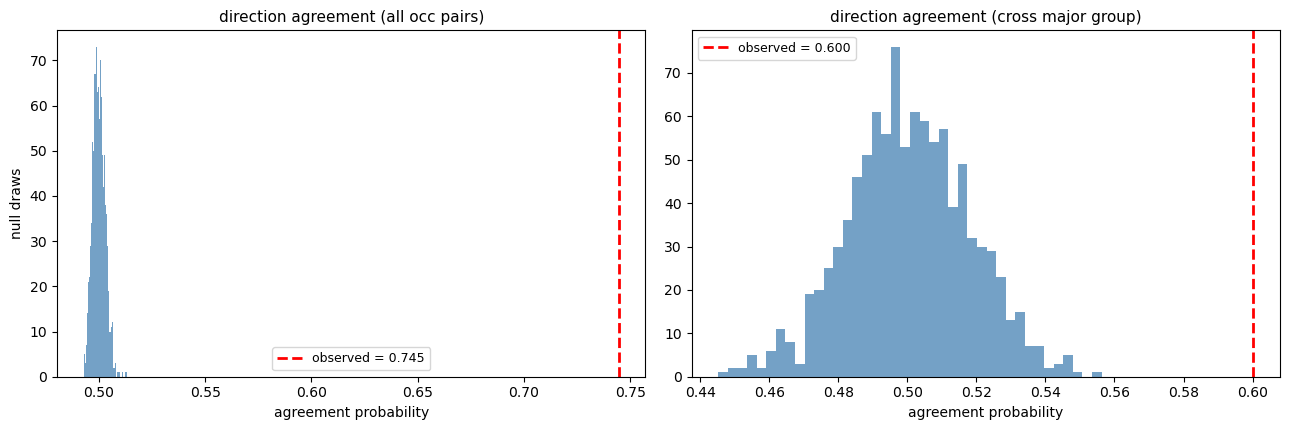

In [8]:
nullB_rows = []
for b in range(N_SHUFFLES):
    order = np.lexsort((rng.random(len(m)), mocc))
    nullB_rows.append(agreement_stats(meanpos_from_order(order)))
nullB = pd.DataFrame(nullB_rows)
nullB.to_csv(f"{output_data_path}/null_draws_measureB.csv", index=False)

print(f"{'statistic':<42}{'observed':>10}{'null mean':>11}{'null sd':>9}{'z':>8}{'p (null >= obs)':>17}")
B_LABEL = {'agree_all': 'direction agreement (all occ pairs)',
           'agree_crossMG': 'direction agreement (cross major group)'}
summaryB = []
for k in ['agree_all', 'agree_crossMG']:
    mu, sd = nullB[k].mean(), nullB[k].std(ddof=1)
    z = (obsB[k] - mu) / sd if sd > 0 else np.nan
    p = (1 + (nullB[k] >= obsB[k]).sum()) / (1 + N_SHUFFLES)
    print(f"{B_LABEL[k]:<42}{obsB[k]:>10.3f}{mu:>11.3f}{sd:>9.4f}{z:>8.2f}{p:>17.4f}")
    summaryB.append({'measure': 'B_direction', 'statistic': k, 'observed': obsB[k],
                     'null_mean': mu, 'null_sd': sd, 'z': z, 'p_onesided_greater': p})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, k in zip(axes, ['agree_all', 'agree_crossMG']):
    ax.hist(nullB[k], bins=40, color='steelblue', alpha=0.75)
    ax.axvline(obsB[k], color='red', ls='--', lw=2, label=f"observed = {obsB[k]:.3f}")
    ax.set_title(B_LABEL[k], fontsize=11)
    ax.set_xlabel('agreement probability'); ax.legend(fontsize=9)
axes[0].set_ylabel('null draws')
fig.tight_layout()
fig.savefig(f"{output_plot_path}/direction_agreement_null.png", dpi=200, bbox_inches='tight')
plt.show()

In [9]:
summary = pd.DataFrame(summaryA + summaryB)
summary.to_csv(f"{output_data_path}/summary_stats.csv", index=False)
print(summary.to_string(index=False))
print("\nSaved summary_stats.csv, top_recurring_dwa_adjacencies.csv, dwa_pair_direction_consistency.csv,")
print("null_draws_measureA.csv, null_draws_measureB.csv ->", output_data_path)

    measure      statistic  observed  null_mean  null_sd         z  p_onesided_greater
A_adjacency  obs_recur_occ  0.157480   0.102125 0.003628 15.258132            0.000999
A_adjacency   obs_recur_mg  0.002821   0.002064 0.000662  1.141811            0.128871
A_adjacency pair_recur_occ  0.067303   0.047707 0.001936 10.119403            0.000999
A_adjacency self_dwa_share  0.131823   0.045871 0.001833 46.895120            0.000999
B_direction      agree_all  0.744509   0.500062 0.002906 84.104514            0.000999
B_direction  agree_crossMG  0.600201   0.500388 0.017672  5.648049            0.000999

Saved summary_stats.csv, top_recurring_dwa_adjacencies.csv, dwa_pair_direction_consistency.csv,
null_draws_measureA.csv, null_draws_measureB.csv -> ../data/computed_objects/dwaOrdering_consistency


## Reading the results

If observed values sit inside the null distributions, task orderings carry no shared cross-occupation DWA logic
beyond what workflow composition mechanically implies, and the cross-occupation neighbor variation used in
Prediction 3 is genuine. Observed values above the null indicate some shared ordering logic; the z-scores and the
gap between observed and null quantify how much. The cross-major-group versions ask whether any such logic
survives outside occupation families, which is the variation the SOC fixed-effects specifications rely on.